# Practice 1. State Simulation 코드

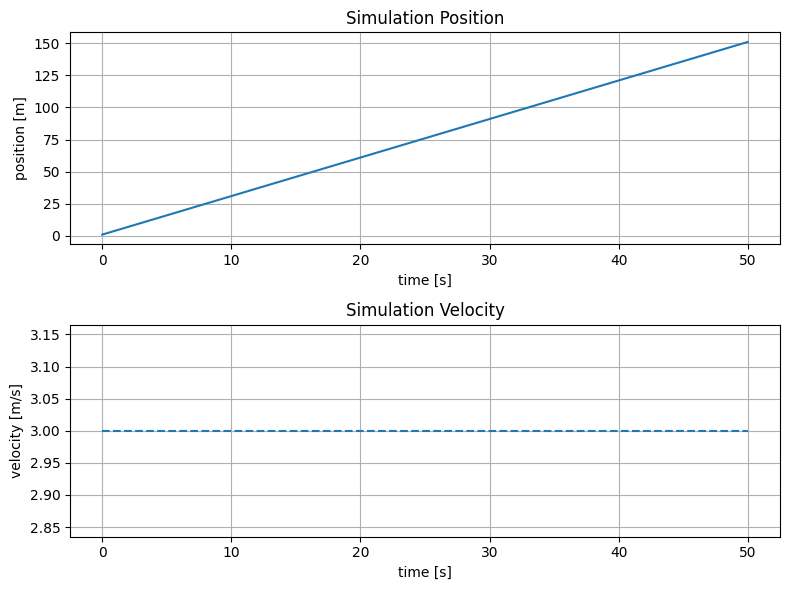

In [1]:
import numpy as np  # 문법: import문과 as 별칭; 의미: NumPy를 np라는 이름으로 불러와 배열과 행렬 계산에 사용합니다.
import matplotlib.pyplot as plt  # 문법: 하위 모듈 import와 별칭; 의미: 그래프를 그리는 pyplot을 plt라는 이름으로 사용합니다.

# =========================================
# 1️⃣ 시뮬레이션 조건 설정
# =========================================
dT = 0.1  # 문법: 변수 대입문; 의미: 이산 시간 간격을 0.1초로 설정합니다.
t_end = 50  # 문법: 변수 대입문; 의미: 시뮬레이션 종료 시간을 50초로 설정합니다.
t = np.arange(0, t_end + dT, dT)  # 문법: 함수 호출 결과를 변수에 대입; 의미: 0초부터 50초까지 0.1초 간격의 시간 벡터를 만듭니다.
N = len(t)  # 문법: 내장 함수 len 호출; 의미: 전체 시간 샘플 개수를 계산합니다.

# =========================================
# 2️⃣ 시스템 행렬 정의
# 상태: x = [l, v]^T
# =========================================
F = np.array([[1.0, dT],  # 문법: np.array로 2차원 리스트의 첫 번째 행을 배열로 변환; 의미: 위치가 이전 위치와 속도*dT만큼 변하도록 정의합니다.
              [0.0, 1.0]])  # 문법: 2차원 리스트의 두 번째 행과 닫는 괄호; 의미: 속도는 이전 속도 그대로 유지되도록 정의합니다.

# =========================================
# 3️⃣ 초기 상태 설정
# l0 = 1 m, v0 = 3 m/s
# =========================================
x = np.array([[1.0],  # 문법: 열벡터 형태의 NumPy 배열 첫 번째 원소; 의미: 초기 위치를 1 m로 설정합니다.
              [3.0]])  # 문법: 열벡터 형태의 NumPy 배열 두 번째 원소; 의미: 초기 속도를 3 m/s로 설정합니다.

x_history = np.zeros((N, 2))  # 문법: np.zeros로 2차원 배열 생성; 의미: 각 시간의 위치와 속도를 저장할 N행 2열 배열을 만듭니다.
x_history[0] = x.flatten()  # 문법: 인덱싱과 flatten 메서드 호출; 의미: 초기 상태 열벡터를 1차원으로 펴서 첫 번째 행에 저장합니다.

# =========================================
# 4️⃣ 상태 시뮬레이션
# x_{k+1} = F x_k
# =========================================
for k in range(1, N):  # 문법: for 반복문과 range; 의미: 두 번째 시간 샘플부터 마지막 샘플까지 상태를 순차적으로 전파합니다.
    x = F @ x  # 문법: 행렬곱 연산자 @와 대입; 의미: 상태 전이 행렬 F를 현재 상태에 곱해 다음 상태를 계산합니다.
    x_history[k] = x.flatten()  # 문법: 배열 인덱싱과 메서드 호출; 의미: 계산된 상태를 1차원으로 바꿔 k번째 시간 기록에 저장합니다.

l_history = x_history[:, 0]  # 문법: 슬라이싱으로 모든 행의 0번 열 선택; 의미: 전체 시간에 대한 위치 기록만 추출합니다.
v_history = x_history[:, 1]  # 문법: 슬라이싱으로 모든 행의 1번 열 선택; 의미: 전체 시간에 대한 속도 기록만 추출합니다.

# =========================================
# 5️⃣ 결과 시각화
# =========================================
plt.figure(figsize=(8, 6))  # 문법: 함수 호출과 키워드 인자; 의미: 8x6인치 크기의 새 그림 창을 만듭니다.

plt.subplot(2, 1, 1)  # 문법: subplot 함수 호출; 의미: 2행 1열 배치 중 첫 번째 축을 선택합니다.
plt.plot(t, l_history)  # 문법: plot 함수 호출; 의미: 시간에 따른 위치 변화를 선 그래프로 그립니다.
plt.grid(True)  # 문법: 함수 호출에 불리언 인자 전달; 의미: 현재 그래프에 격자선을 켭니다.
plt.title("Simulation Position")  # 문법: 문자열 인자를 넘기는 함수 호출; 의미: 위치 그래프 제목을 설정합니다.
plt.xlabel("time [s]")  # 문법: 문자열 인자를 넘기는 함수 호출; 의미: x축 라벨을 시간 단위로 표시합니다.
plt.ylabel("position [m]")  # 문법: 문자열 인자를 넘기는 함수 호출; 의미: y축 라벨을 위치 단위로 표시합니다.

plt.subplot(2, 1, 2)  # 문법: subplot 함수 호출; 의미: 2행 1열 배치 중 두 번째 축을 선택합니다.
plt.plot(t, v_history, linestyle="--")  # 문법: 함수 호출과 키워드 인자; 의미: 시간에 따른 속도를 점선 그래프로 그립니다.
plt.grid(True)  # 문법: 함수 호출에 불리언 인자 전달; 의미: 속도 그래프에 격자선을 켭니다.
plt.title("Simulation Velocity")  # 문법: 문자열 인자를 넘기는 함수 호출; 의미: 속도 그래프 제목을 설정합니다.
plt.xlabel("time [s]")  # 문법: 문자열 인자를 넘기는 함수 호출; 의미: x축 라벨을 시간 단위로 표시합니다.
plt.ylabel("velocity [m/s]")  # 문법: 문자열 인자를 넘기는 함수 호출; 의미: y축 라벨을 속도 단위로 표시합니다.

plt.tight_layout()  # 문법: 함수 호출; 의미: subplot 사이 간격을 자동으로 정리합니다.
plt.show()  # 문법: 함수 호출; 의미: 완성된 그림을 화면에 출력합니다.


# Practice 2. Measurement Simulation 코드

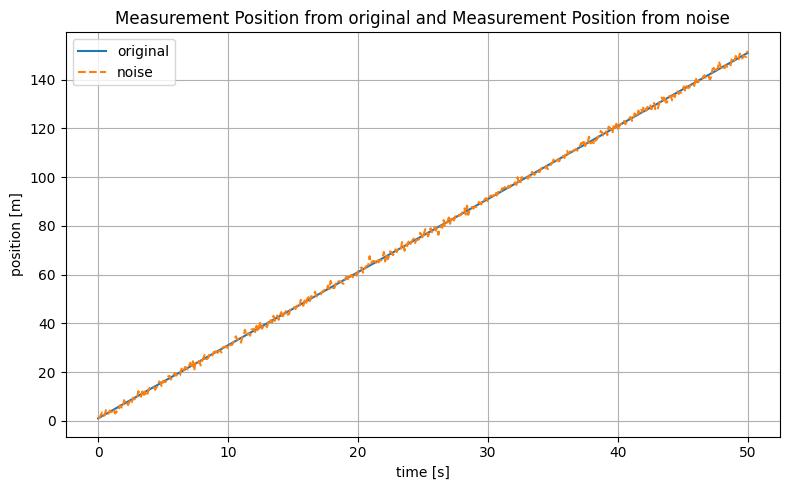

In [2]:
import numpy as np  # 문법: import문과 as 별칭; 의미: NumPy를 np라는 이름으로 불러와 수치 계산에 사용합니다.
import matplotlib.pyplot as plt  # 문법: 하위 모듈 import와 별칭; 의미: Matplotlib의 그래프 기능을 plt로 사용합니다.
from scipy.io import savemat  # 문법: from-import문; 의미: SciPy에서 MATLAB .mat 파일 저장 함수 savemat만 가져옵니다.

# =========================================
# 1️⃣ 시뮬레이션 조건 설정
# =========================================
dT = 0.1  # 문법: 변수 대입문; 의미: 이산 시간 간격을 0.1초로 설정합니다.
t_end = 50  # 문법: 변수 대입문; 의미: 시뮬레이션을 50초까지 수행하도록 설정합니다.
t = np.arange(0, t_end + dT, dT)  # 문법: NumPy 함수 호출 결과 대입; 의미: 0초부터 50초까지의 시간 배열을 생성합니다.
N = len(t)  # 문법: 내장 함수 len 호출; 의미: 시간 배열의 길이, 즉 샘플 개수를 구합니다.

# =========================================
# 2️⃣ 시스템 행렬 및 측정 행렬 정의
# 상태: x = [l, v]^T
# 측정: y = Hx + w
# =========================================
F = np.array([[1.0, dT],  # 문법: np.array에 중첩 리스트 전달; 의미: 위치가 속도에 따라 갱신되는 상태 전이 행렬 첫 행입니다.
              [0.0, 1.0]])  # 문법: 배열 리터럴의 두 번째 행; 의미: 속도가 일정하게 유지되는 상태 전이 행렬 둘째 행입니다.

H = np.array([[1.0, 0.0]])  # 문법: 1행 2열 NumPy 배열 생성; 의미: 상태 중 위치 성분만 측정값으로 뽑는 측정 행렬입니다.

# =========================================
# 3️⃣ 초기 상태 설정
# l0 = 1 m, v0 = 3 m/s
# =========================================
x = np.array([[1.0],  # 문법: 2차원 배열의 첫 번째 행; 의미: 초기 위치를 1 m로 둡니다.
              [3.0]])  # 문법: 2차원 배열의 두 번째 행; 의미: 초기 속도를 3 m/s로 둡니다.

x_history = np.zeros((N, 2))  # 문법: 튜플 형태 shape을 넘기는 배열 생성; 의미: 모든 시간의 실제 위치와 속도를 저장할 공간을 만듭니다.
x_history[0] = x.flatten()  # 문법: 배열 인덱싱과 flatten 호출; 의미: 초기 상태를 첫 번째 행에 저장합니다.

# =========================================
# 4️⃣ Ground Truth 상태 시뮬레이션
# =========================================
for k in range(1, N):  # 문법: for 반복문; 의미: 시간 인덱스 1부터 N-1까지 실제 상태를 전파합니다.
    x = F @ x  # 문법: 행렬곱 연산자 @; 의미: 이전 상태에 F를 곱해 다음 실제 상태를 계산합니다.
    x_history[k] = x.flatten()  # 문법: 배열 대입과 flatten 메서드; 의미: 계산한 상태를 기록 배열의 k번째 행에 저장합니다.

l_history = x_history[:, 0]  # 문법: 전체 행과 첫 번째 열을 선택하는 슬라이싱; 의미: 실제 위치 시계열을 추출합니다.
v_history = x_history[:, 1]  # 문법: 전체 행과 두 번째 열을 선택하는 슬라이싱; 의미: 실제 속도 시계열을 추출합니다.

# =========================================
# 5️⃣ 측정 노이즈 생성
# w ~ N(0, sigma^2), sigma = 1 m
# =========================================
np.random.seed(42)  # 문법: 난수 시드 설정 함수 호출; 의미: 매번 같은 노이즈가 나오도록 재현성을 고정합니다.

sigma = 1.0  # 문법: 변수 대입문; 의미: 측정 노이즈의 표준편차를 1 m로 설정합니다.
w = np.random.normal(0, sigma, N)  # 문법: 정규분포 난수 생성 함수 호출; 의미: 평균 0, 표준편차 sigma인 노이즈 N개를 생성합니다.

# =========================================
# 6️⃣ 측정값 생성
# y_k = H x_k + w_k
# H = [1, 0] 이므로 위치만 측정
# =========================================
y_history = l_history + w  # 문법: 배열끼리 원소별 덧셈; 의미: 실제 위치에 측정 노이즈를 더해 위치 측정값을 만듭니다.

# =========================================
# 7️⃣ .mat 파일 저장
# =========================================
savemat("measurement_simulation.mat", {  # 문법: 함수 호출과 딕셔너리 인자 시작; 의미: 시간, 실제 상태, 측정값, 노이즈를 MATLAB 파일로 저장합니다.
    "t": t,  # 문법: 딕셔너리 키-값 쌍; 의미: 시간 배열을 t라는 이름으로 저장합니다.
    "l_true": l_history,  # 문법: 딕셔너리 키-값 쌍; 의미: 실제 위치 기록을 저장합니다.
    "v_true": v_history,  # 문법: 딕셔너리 키-값 쌍; 의미: 실제 속도 기록을 저장합니다.
    "y_measurement": y_history,  # 문법: 딕셔너리 키-값 쌍; 의미: 노이즈가 포함된 측정 위치를 저장합니다.
    "noise": w,  # 문법: 딕셔너리 키-값 쌍; 의미: 생성한 측정 노이즈 자체를 저장합니다.
    "dT": dT,  # 문법: 딕셔너리 키-값 쌍; 의미: 시간 간격 값도 함께 저장합니다.
    "sigma": sigma  # 문법: 딕셔너리 키-값 쌍; 의미: 노이즈 표준편차 값을 함께 저장합니다.
})  # 문법: 함수 호출과 딕셔너리 닫기; 의미: .mat 파일 저장 명령을 완료합니다.

# =========================================
# 8️⃣ 결과 시각화
# =========================================
plt.figure(figsize=(8, 5))  # 문법: 함수 호출과 키워드 인자; 의미: 8x5인치 크기의 새 그래프 창을 만듭니다.

plt.plot(t, l_history, label="original")  # 문법: plot 함수 호출과 label 키워드; 의미: 실제 위치를 original이라는 범례 이름으로 그립니다.
plt.plot(t, y_history, linestyle="--", label="noise")  # 문법: plot 함수 호출과 키워드 인자; 의미: 노이즈가 섞인 측정 위치를 점선으로 그립니다.

plt.grid(True)  # 문법: 함수 호출에 불리언 인자 전달; 의미: 그래프 격자선을 켭니다.
plt.title("Measurement Position from original and Measurement Position from noise")  # 문법: 문자열 인자를 넘기는 함수 호출; 의미: 실제 위치와 측정 위치 비교 그래프 제목을 설정합니다.
plt.xlabel("time [s]")  # 문법: 문자열 인자를 넘기는 함수 호출; 의미: x축을 시간 단위로 표시합니다.
plt.ylabel("position [m]")  # 문법: 문자열 인자를 넘기는 함수 호출; 의미: y축을 위치 단위로 표시합니다.
plt.legend()  # 문법: 함수 호출; 의미: label로 지정한 범례를 그래프에 표시합니다.

plt.tight_layout()  # 문법: 함수 호출; 의미: 그래프 요소 간 간격을 보기 좋게 조정합니다.
plt.show()  # 문법: 함수 호출; 의미: 그래프를 화면에 출력합니다.


# 📋 Practice 4-1. State Simulation (Constant Velocity Model)

## ■ 시스템 모델 (Process Equation)

- l_{t+1} = l_t + dT · v_t
- v_{t+1} = v_t

```
[l]      = [1  dT] [l]
[v]_{t+1}  [0   1] [v]_t
```

> 가속도 = 0 (등속 운동, Constant Velocity)
> 노이즈 없음 (Ground truth 생성)

## ■ 조건

- 샘플링 시간: dT = 0.1 s
- 초기 위치: l_0 = 1 m
- 초기 속도: v_0 = 3 m/s
- 시뮬레이션 구간: t = 0 ~ 50 s (총 501 step)

## ■ 풀이 절차

### 1️⃣ 시스템 행렬 정의
- 상태 전이 행렬 F (2×2) 정의
- F = [[1, dT], [0, 1]]

### 2️⃣ 초기 상태 설정
- 초기 상태 벡터 x_0 = [l_0, v_0]ᵀ = [1, 3]ᵀ
- 시간 배열 t = 0, 0.1, 0.2, ..., 50

### 3️⃣ 저장 배열 준비
- 각 시간 step의 상태값 저장 배열 생성
- N×2 크기 (N = 시간 step 개수)

### 4️⃣ 시간 루프 (State Propagation)
- 매 step마다 x_{k+1} = F · x_k 반복 계산
- 결과를 배열에 저장

### 5️⃣ 결과 시각화
- 위 그래프: 위치 l_t (시간에 따라 선형 증가)
- 아래 그래프: 속도 v_t (3 m/s로 일정)

---

## ■ 한줄 정리

> 👉 "노이즈 없이, CV 모델로 차량의 진짜 상태(l_t, v_t)를 생성하는 단계"
> 👉 이 결과는 나중에 4-2의 측정값 생성과 4-3의 칼만필터 검증에 사용됨

---

## 💡 헷갈리기 쉬운 포인트

- **노이즈 X**: 4-1은 deterministic 시뮬레이션. Q, w 같은 거 없음
- **상태 차원**: 자유낙하(3개: r, v, a)와 달리 CV는 **2개 (l, v)**
- **시간 step 개수**: t = 0~50, dT = 0.1이면 N = 501개 (양 끝 포함)
- **이 결과 = Ground Truth**: 4-3에서 추정값과 비교할 "정답"

In [ ]:
import numpy as np  # 문법: import문과 as 별칭; 의미: NumPy를 np라는 이름으로 불러와 배열 계산에 사용합니다.
import matplotlib.pyplot as plt  # 문법: 하위 모듈 import와 별칭; 의미: 그래프 작성 기능을 plt라는 이름으로 사용합니다.

# ---- 시뮬레이션 조건 ----
dT    = 0.1  # 문법: 변수 대입문; 의미: 샘플링 시간 간격을 0.1초로 설정합니다.
t_end = 50  # 문법: 변수 대입문; 의미: 시뮬레이션 종료 시간을 50초로 설정합니다.
t     = np.arange(0, t_end + dT, dT)  # 문법: NumPy 함수 호출 결과 대입; 의미: 전체 시뮬레이션 시간 벡터를 만듭니다.
N     = len(t)  # 문법: 내장 함수 len 호출; 의미: 시간 샘플 개수를 계산합니다.

# ---- 시스템 행렬 ----
F = np.array([[1.0, dT],  # 문법: np.array로 행렬 첫 행 생성; 의미: 위치가 이전 위치와 속도*dT로 갱신됨을 나타냅니다.
              [0.0, 1.0]])  # 문법: 행렬 두 번째 행과 닫는 괄호; 의미: 속도는 한 스텝 뒤에도 그대로 유지됩니다.
H = np.array([[1.0, 0.0]])  # 문법: 1행 2열 배열 생성; 의미: 상태 벡터에서 위치만 측정하도록 선택합니다.

# ---- True State 시뮬레이션 (Ground Truth) ----
x         = np.array([[1.0], [3.0]])  # 문법: 2행 1열 NumPy 배열 대입; 의미: 초기 위치 1 m, 초기 속도 3 m/s인 상태 벡터를 만듭니다.
x_history = np.zeros((N, 2))  # 문법: np.zeros에 shape 튜플 전달; 의미: 실제 상태 기록을 저장할 N행 2열 배열을 초기화합니다.
x_history[0] = x.flatten()  # 문법: 배열 인덱싱과 flatten 호출; 의미: 초기 상태를 1차원으로 바꾸어 첫 번째 기록에 넣습니다.
for k in range(1, N):  # 문법: for 반복문; 의미: 두 번째 샘플부터 마지막 샘플까지 실제 상태를 계산합니다.
    x = F @ x  # 문법: 행렬곱 연산자 @와 대입; 의미: 상태 전이식 x_k = F x_{k-1}을 적용합니다.
    x_history[k] = x.flatten()  # 문법: 배열 인덱싱과 flatten 호출; 의미: 현재 상태 열벡터를 한 행 형태로 저장합니다.

# ---- 측정값 생성 (y = Hx + w, w ~ N(0, σ²)) ----
np.random.seed(42)  # 문법: 난수 발생기 시드 설정; 의미: 동일한 노이즈가 반복 생성되도록 고정합니다.
sigma     = 1.0  # 문법: 변수 대입문; 의미: 측정 노이즈 표준편차를 1.0으로 둡니다.
w         = np.random.normal(0, sigma, N)  # 문법: 정규분포 난수 생성 함수 호출; 의미: 평균 0, 표준편차 sigma인 측정 노이즈 N개를 생성합니다.
y_history = x_history[:, 0] + w  # 문법: 슬라이싱과 배열 덧셈; 의미: 실제 위치에 노이즈를 더해 측정 위치 시계열을 만듭니다.


In [4]:
def kalman_filter(F, H, Q, R, x_0, P_0, y_meas):  # 문법: 함수 정의와 매개변수 목록; 의미: 주어진 모델과 측정값으로 이산 시간 칼만 필터를 수행하는 함수를 만듭니다.
    N = len(y_meas)  # 문법: 내장 함수 len 호출; 의미: 측정값 개수를 필터 반복 횟수로 사용합니다.
    n = F.shape[0]  # 문법: 배열 속성 shape 인덱싱; 의미: 상태 전이 행렬의 행 개수로 상태 차원을 구합니다.

    x_hat_hist   = np.zeros((N, n))  # 문법: 2차원 0 배열 생성; 의미: 각 시간의 사후 상태 추정값을 저장할 배열을 만듭니다.
    P_prior_hist = np.zeros((N, n, n))  # 문법: 3차원 0 배열 생성; 의미: 각 시간의 예측 공분산 P_prior를 저장할 배열을 만듭니다.
    P_post_hist  = np.zeros((N, n, n))  # 문법: 3차원 0 배열 생성; 의미: 각 시간의 갱신 후 공분산 P_post를 저장할 배열을 만듭니다.

    x_hat = x_0.copy()  # 문법: 객체 메서드 copy 호출; 의미: 초기 추정 상태를 원본과 분리해서 필터 내부 상태로 사용합니다.
    P     = P_0.copy()  # 문법: 객체 메서드 copy 호출; 의미: 초기 공분산을 원본과 분리해서 필터 내부 공분산으로 사용합니다.
    I     = np.eye(n)  # 문법: 단위행렬 생성 함수 호출; 의미: 공분산 갱신식에 사용할 n차원 단위행렬을 만듭니다.
    R     = np.atleast_2d(R)  # 문법: 배열 차원 보정 함수 호출; 의미: R이 스칼라여도 행렬 연산이 가능하도록 최소 2차원 배열로 바꿉니다.

    for k in range(N):  # 문법: for 반복문; 의미: 모든 측정 시점에 대해 예측 단계와 갱신 단계를 반복합니다.
        # ---- Prediction ----
        x_hat = F @ x_hat  # 문법: 행렬곱 연산자 @; 의미: 이전 사후 추정값으로 현재 시점의 사전 상태를 예측합니다.
        P     = F @ P @ F.T + Q  # 문법: 연속 행렬곱, 전치 속성 T, 배열 덧셈; 의미: 상태 전이와 과정 잡음을 반영해 사전 공분산을 예측합니다.
        P_prior_hist[k] = P  # 문법: 3차원 배열 인덱싱 대입; 의미: 현재 시점의 예측 공분산을 저장합니다.

        # ---- Update ----
        S          = H @ P @ H.T + R  # 문법: 행렬곱과 덧셈; 의미: 측정 예측 오차의 공분산, 즉 innovation covariance를 계산합니다.
        K          = P @ H.T @ np.linalg.inv(S)  # 문법: 행렬곱과 역행렬 함수 호출; 의미: 예측값과 측정값을 얼마나 섞을지 정하는 칼만 이득을 계산합니다.
        y_k        = np.array([[y_meas[k]]])  # 문법: 인덱싱한 값을 2차원 배열로 감싸기; 의미: k번째 측정값을 행렬 연산용 열벡터 형태로 만듭니다.
        innovation = y_k - H @ x_hat  # 문법: 배열 뺄셈과 행렬곱; 의미: 실제 측정값과 예측 측정값의 차이를 계산합니다.
        x_hat      = x_hat + K @ innovation  # 문법: 배열 덧셈과 행렬곱; 의미: innovation을 칼만 이득만큼 반영해 상태 추정값을 보정합니다.
        P          = (I - K @ H) @ P  # 문법: 괄호로 우선순위 지정 후 행렬곱; 의미: 측정 갱신 후 불확실성이 줄어든 사후 공분산을 계산합니다.
        P_post_hist[k] = P  # 문법: 3차원 배열 인덱싱 대입; 의미: 현재 시점의 사후 공분산을 저장합니다.

        x_hat_hist[k] = x_hat.flatten()  # 문법: 배열 인덱싱과 flatten 호출; 의미: 현재 사후 상태 추정값을 1차원 행으로 저장합니다.

    return x_hat_hist, P_prior_hist, P_post_hist  # 문법: return문과 튜플 반환; 의미: 상태 추정 기록, 예측 공분산 기록, 사후 공분산 기록을 함수 밖으로 돌려줍니다.


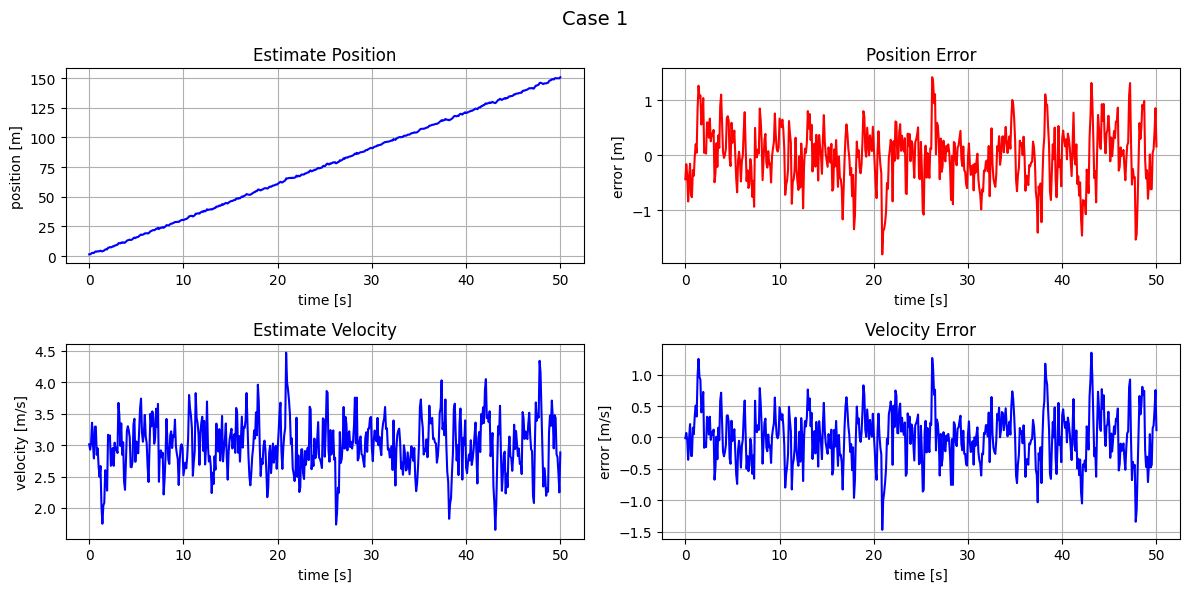

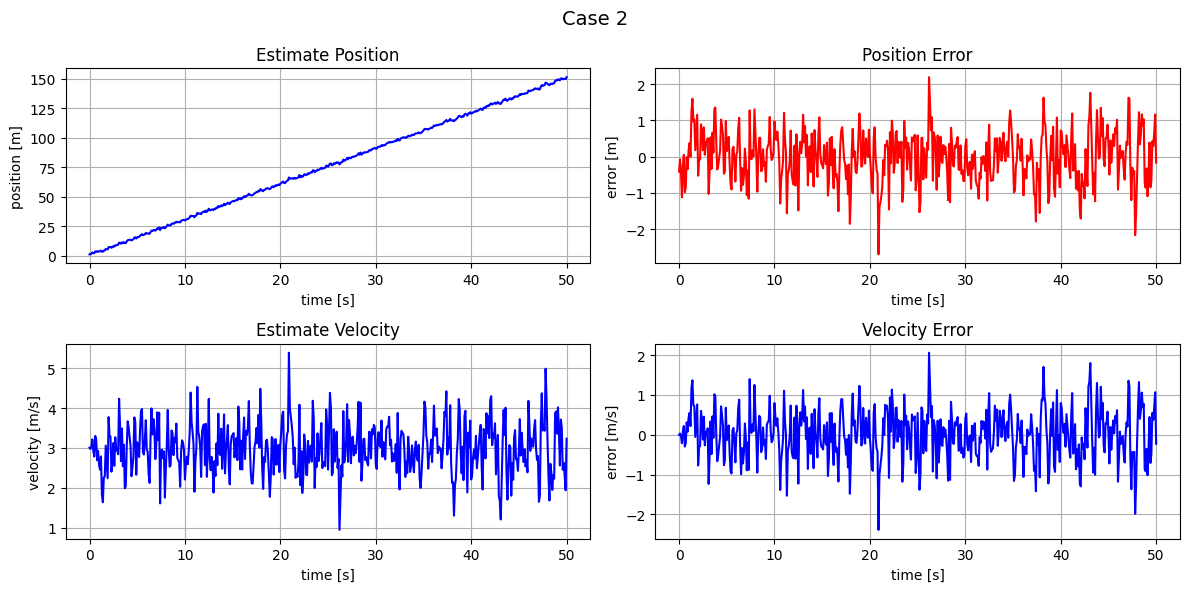

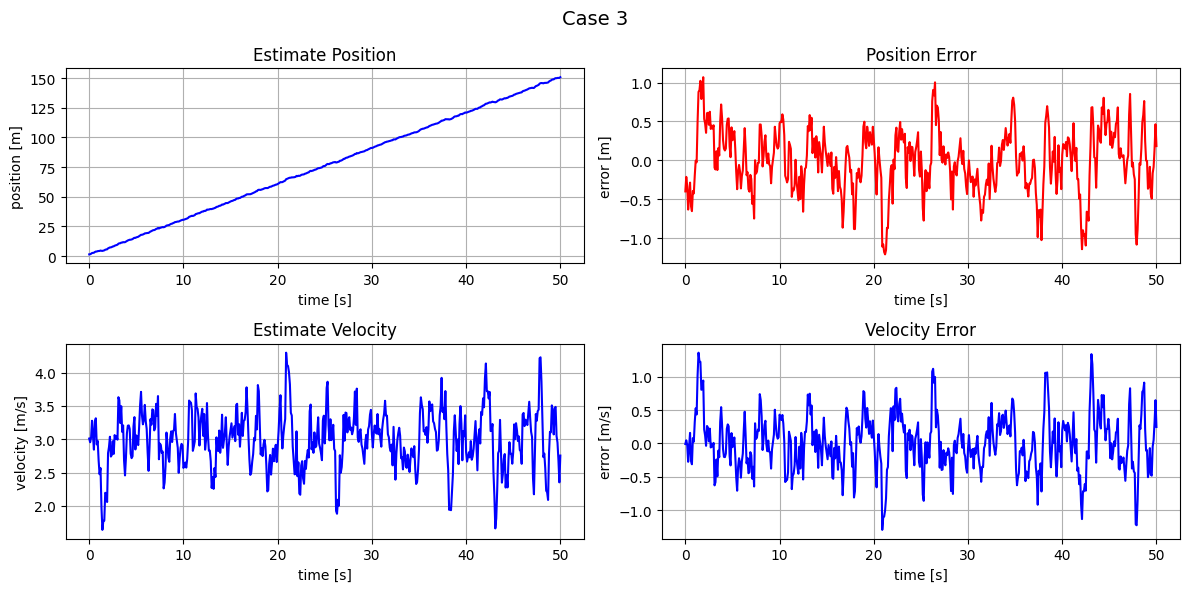

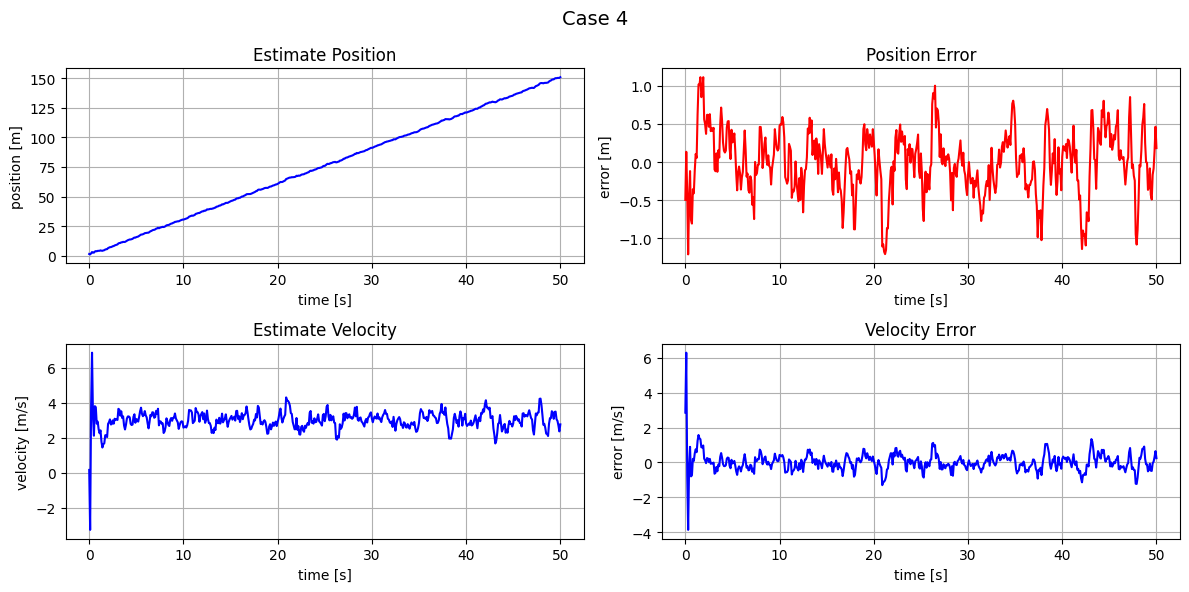

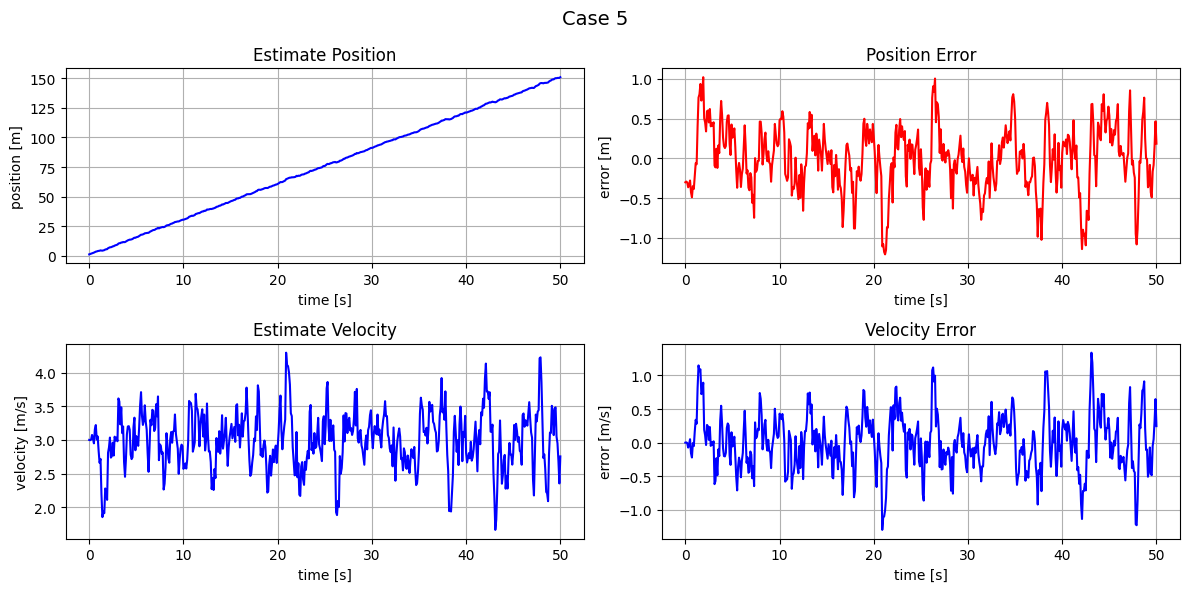

In [5]:
cases = {  # 문법: 딕셔너리 리터럴 시작; 의미: 서로 다른 칼만 필터 파라미터 실험 조건들을 묶어 둡니다.
    'Case 1': {  # 문법: 문자열 키와 중첩 딕셔너리 시작; 의미: 첫 번째 실험 조건을 정의합니다.
        'Q': np.diag([0.1, 0.1]), 'R': 0.5,  # 문법: 키-값 쌍과 np.diag 함수 호출; 의미: 작은 과정 잡음 Q와 비교적 작은 측정 잡음 R을 설정합니다.
        'x_0': np.array([[1.0], [3.0]]), 'P_0': np.diag([1.0, 1.0])  # 문법: 키-값 쌍과 배열 생성; 의미: 정확한 초기 상태와 단위 초기 공분산을 설정합니다.
    },  # 문법: 중첩 딕셔너리 종료; 의미: Case 1 설정을 마칩니다.
    'Case 2': {  # 문법: 문자열 키와 중첩 딕셔너리 시작; 의미: 두 번째 실험 조건을 정의합니다.
        'Q': np.diag([3.0, 3.0]), 'R': 3.0,  # 문법: 키-값 쌍과 대각행렬 생성; 의미: 과정 잡음과 측정 잡음을 크게 설정합니다.
        'x_0': np.array([[1.0], [3.0]]), 'P_0': np.diag([1.0, 1.0])  # 문법: 키-값 쌍; 의미: 초기 상태는 실제값과 같고 초기 공분산은 1로 둡니다.
    },  # 문법: 중첩 딕셔너리 종료; 의미: Case 2 설정을 마칩니다.
    'Case 3': {  # 문법: 문자열 키와 중첩 딕셔너리 시작; 의미: 세 번째 실험 조건을 정의합니다.
        'Q': np.diag([0.01, 0.1]), 'R': 1.0,  # 문법: 키-값 쌍과 대각행렬 생성; 의미: 위치 과정 잡음은 작게, 속도 과정 잡음은 상대적으로 크게 둡니다.
        'x_0': np.array([[1.0], [3.0]]), 'P_0': np.diag([1.0, 1.0])  # 문법: 키-값 쌍; 의미: 정확한 초기 상태와 보통 크기의 초기 불확실성을 둡니다.
    },  # 문법: 중첩 딕셔너리 종료; 의미: Case 3 설정을 마칩니다.
    'Case 4': {  # 문법: 문자열 키와 중첩 딕셔너리 시작; 의미: 네 번째 실험 조건을 정의합니다.
        'Q': np.diag([0.01, 0.1]), 'R': 1.0,  # 문법: 키-값 쌍; 의미: Case 3과 같은 Q, R을 사용합니다.
        'x_0': np.array([[0.0], [0.0]]), 'P_0': np.diag([10000.0, 10000.0])  # 문법: 배열과 대각행렬 생성; 의미: 틀린 초기 상태지만 초기 불확실성을 매우 크게 둡니다.
    },  # 문법: 중첩 딕셔너리 종료; 의미: Case 4 설정을 마칩니다.
    'Case 5': {  # 문법: 문자열 키와 중첩 딕셔너리 시작; 의미: 다섯 번째 실험 조건을 정의합니다.
        'Q': np.diag([0.01, 0.1]), 'R': 1.0,  # 문법: 키-값 쌍; 의미: Case 3과 같은 Q, R을 사용합니다.
        'x_0': np.array([[1.0], [3.0]]), 'P_0': np.diag([0.0, 0.0])  # 문법: 배열과 대각행렬 생성; 의미: 초기 상태는 맞지만 초기 불확실성을 0으로 두어 필터가 얼마나 경직되는지 봅니다.
    },  # 문법: 중첩 딕셔너리 종료; 의미: Case 5 설정을 마칩니다.
}  # 문법: 바깥 딕셔너리 종료; 의미: 모든 실험 케이스 정의를 완료합니다.

results = {}  # 문법: 빈 딕셔너리 생성; 의미: 각 케이스의 추정 결과와 RMSE를 저장할 공간을 만듭니다.
for name, p in cases.items():  # 문법: 딕셔너리 items 순회; 의미: 케이스 이름과 파라미터 묶음을 하나씩 꺼내 필터를 실행합니다.
    x_hat_hist, P_prior_hist, P_post_hist = kalman_filter(  # 문법: 함수 호출 결과를 여러 변수에 언패킹; 의미: 칼만 필터의 상태 추정과 공분산 기록을 받습니다.
        F, H, p['Q'], p['R'], p['x_0'], p['P_0'], y_history  # 문법: 위치 인자와 딕셔너리 값 접근; 의미: 현재 케이스의 Q, R, 초기값과 측정값을 함수에 전달합니다.
    )  # 문법: 함수 호출 닫기; 의미: 현재 케이스에 대한 필터 실행을 완료합니다.
    err_pos = x_history[:, 0] - x_hat_hist[:, 0]  # 문법: 슬라이싱과 배열 뺄셈; 의미: 실제 위치와 추정 위치의 오차를 계산합니다.
    err_vel = x_history[:, 1] - x_hat_hist[:, 1]  # 문법: 슬라이싱과 배열 뺄셈; 의미: 실제 속도와 추정 속도의 오차를 계산합니다.
    results[name] = {  # 문법: 딕셔너리 특정 키에 중첩 딕셔너리 대입; 의미: 현재 케이스 결과를 이름별로 저장합니다.
        'x_hat':    x_hat_hist,  # 문법: 키-값 쌍; 의미: 상태 추정 기록을 저장합니다.
        'P_prior':  P_prior_hist,  # 문법: 키-값 쌍; 의미: 예측 공분산 기록을 저장합니다.
        'P_post':   P_post_hist,  # 문법: 키-값 쌍; 의미: 갱신 후 공분산 기록을 저장합니다.
        'rmse_pos': np.sqrt(np.mean(err_pos**2)),  # 문법: 거듭제곱, 평균, 제곱근 함수 호출; 의미: 위치 RMSE를 계산해 저장합니다.
        'rmse_vel': np.sqrt(np.mean(err_vel**2)),  # 문법: 거듭제곱, 평균, 제곱근 함수 호출; 의미: 속도 RMSE를 계산해 저장합니다.
    }  # 문법: 결과 딕셔너리 종료; 의미: 현재 케이스 저장 내용을 마칩니다.

# Practice 3-1: 추정 상태 + 오차 plot
for name in cases:  # 문법: 딕셔너리 키 순회; 의미: 각 케이스 이름별로 그래프를 하나씩 그립니다.
    x_hat = results[name]['x_hat']  # 문법: 중첩 딕셔너리 접근; 의미: 현재 케이스의 상태 추정 기록을 꺼냅니다.
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))  # 문법: 함수 반환값 언패킹과 키워드 인자; 의미: 2x2 subplot과 figure 객체를 만듭니다.
    fig.suptitle(name, fontsize=14)  # 문법: 객체 메서드 호출과 키워드 인자; 의미: 전체 그림의 제목을 케이스 이름으로 표시합니다.

    axes[0, 0].plot(t, x_hat[:, 0], 'b-')  # 문법: 2차원 배열 인덱싱 후 메서드 호출; 의미: 왼쪽 위 축에 추정 위치를 파란 실선으로 그립니다.
    axes[0, 0].set_title('Estimate Position')  # 문법: 축 객체 메서드 호출; 의미: 추정 위치 그래프 제목을 설정합니다.
    axes[0, 0].set_xlabel('time [s]'); axes[0, 0].set_ylabel('position [m]')  # 문법: 세미콜론으로 두 메서드 호출을 한 줄에 작성; 의미: 추정 위치 그래프의 x축과 y축 라벨을 설정합니다.
    axes[0, 0].grid(True)  # 문법: 축 객체 메서드 호출; 의미: 추정 위치 그래프에 격자선을 켭니다.

    axes[1, 0].plot(t, x_hat[:, 1], 'b-')  # 문법: 슬라이싱과 plot 메서드 호출; 의미: 왼쪽 아래 축에 추정 속도를 파란 실선으로 그립니다.
    axes[1, 0].set_title('Estimate Velocity')  # 문법: 축 객체 메서드 호출; 의미: 추정 속도 그래프 제목을 설정합니다.
    axes[1, 0].set_xlabel('time [s]'); axes[1, 0].set_ylabel('velocity [m/s]')  # 문법: 세미콜론으로 두 메서드 호출을 한 줄에 작성; 의미: 추정 속도 그래프의 축 라벨을 설정합니다.
    axes[1, 0].grid(True)  # 문법: 축 객체 메서드 호출; 의미: 추정 속도 그래프에 격자선을 켭니다.

    axes[0, 1].plot(t, x_history[:, 0] - x_hat[:, 0], 'r-')  # 문법: 배열 뺄셈 결과를 plot에 전달; 의미: 오른쪽 위 축에 위치 추정 오차를 빨간 실선으로 그립니다.
    axes[0, 1].set_title('Position Error')  # 문법: 축 객체 메서드 호출; 의미: 위치 오차 그래프 제목을 설정합니다.
    axes[0, 1].set_xlabel('time [s]'); axes[0, 1].set_ylabel('error [m]')  # 문법: 세미콜론으로 두 메서드 호출을 한 줄에 작성; 의미: 위치 오차 그래프의 축 라벨을 설정합니다.
    axes[0, 1].grid(True)  # 문법: 축 객체 메서드 호출; 의미: 위치 오차 그래프에 격자선을 켭니다.

    axes[1, 1].plot(t, x_history[:, 1] - x_hat[:, 1], 'b-')  # 문법: 배열 뺄셈 결과를 plot에 전달; 의미: 오른쪽 아래 축에 속도 추정 오차를 파란 실선으로 그립니다.
    axes[1, 1].set_title('Velocity Error')  # 문법: 축 객체 메서드 호출; 의미: 속도 오차 그래프 제목을 설정합니다.
    axes[1, 1].set_xlabel('time [s]'); axes[1, 1].set_ylabel('error [m/s]')  # 문법: 세미콜론으로 두 메서드 호출을 한 줄에 작성; 의미: 속도 오차 그래프의 축 라벨을 설정합니다.
    axes[1, 1].grid(True)  # 문법: 축 객체 메서드 호출; 의미: 속도 오차 그래프에 격자선을 켭니다.

    plt.tight_layout()  # 문법: 함수 호출; 의미: subplot 간격을 자동으로 정리합니다.
    plt.show()  # 문법: 함수 호출; 의미: 현재 케이스의 그래프를 화면에 출력합니다.


In [6]:
# Practice 3-2: 5개 케이스 RMSE 비교
print(f"{'Case':<10} {'RMSE Position':>18} {'RMSE Velocity':>18}")  # 문법: f-string과 format specifier를 쓰는 print 호출; 의미: 케이스명, 위치 RMSE, 속도 RMSE 표 헤더를 정렬해 출력합니다.
print("-" * 48)  # 문법: 문자열 반복 연산과 print 호출; 의미: 표 헤더 아래에 구분선을 48글자 길이로 출력합니다.
for name, res in results.items():  # 문법: 딕셔너리 items 순회와 튜플 언패킹; 의미: 각 케이스 이름과 결과 딕셔너리를 하나씩 꺼냅니다.
    print(f"{name:<10} {res['rmse_pos']:>18.6f} {res['rmse_vel']:>18.6f}")  # 문법: f-string 내부 딕셔너리 접근과 소수점 포맷; 의미: 각 케이스의 위치/속도 RMSE를 보기 좋게 출력합니다.


Case            RMSE Position      RMSE Velocity
------------------------------------------------
Case 1               0.516898           0.418441
Case 2               0.688100           0.620326
Case 3               0.407137           0.421874
Case 4               0.413861           0.559031
Case 5               0.402695           0.415960


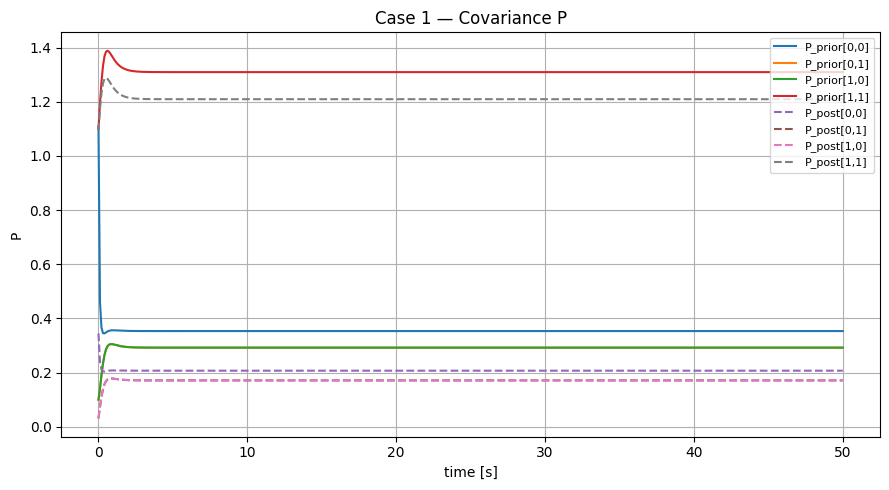

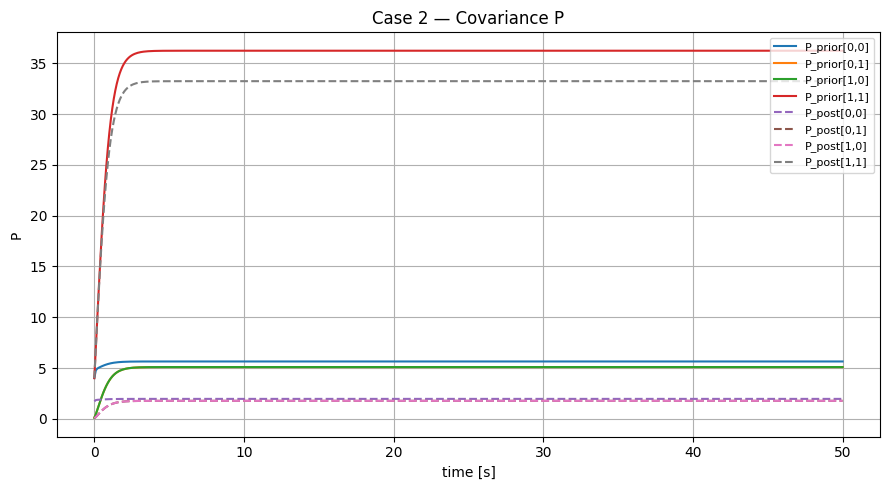

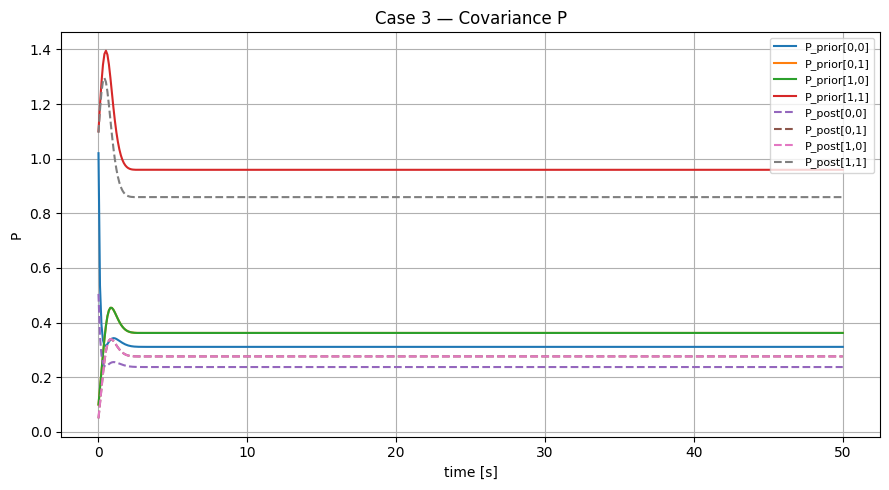

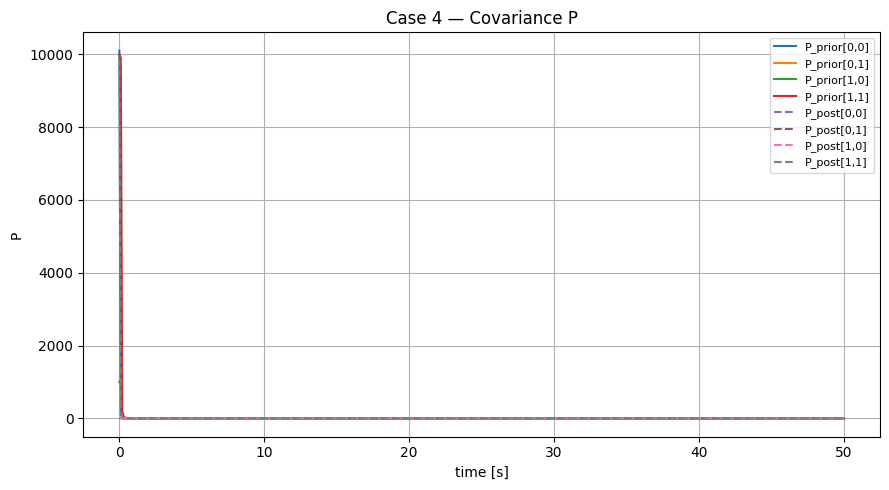

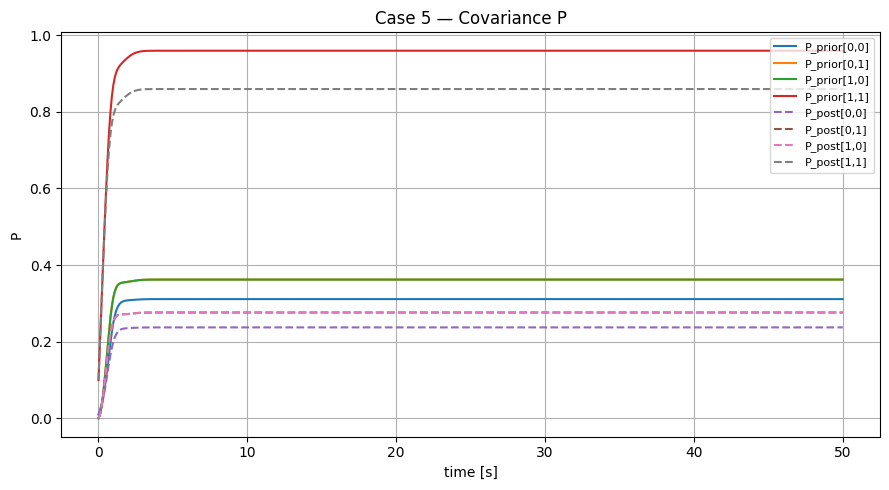

In [7]:
# Practice 3-3: 공분산 P 추적 plot
for name in cases:  # 문법: 딕셔너리 키 순회; 의미: 각 케이스에 대해 공분산 변화 그래프를 그립니다.
    P_prior = results[name]['P_prior']  # 문법: 중첩 딕셔너리 접근; 의미: 현재 케이스의 예측 공분산 기록을 꺼냅니다.
    P_post  = results[name]['P_post']  # 문법: 중첩 딕셔너리 접근; 의미: 현재 케이스의 갱신 후 공분산 기록을 꺼냅니다.

    plt.figure(figsize=(9, 5))  # 문법: 함수 호출과 키워드 인자; 의미: 9x5인치 크기의 새 그림을 만듭니다.
    plt.plot(t, P_prior[:, 0, 0], '-',  label='P_prior[0,0]')  # 문법: 3차원 배열 슬라이싱과 plot 호출; 의미: 예측 공분산의 위치-위치 성분 변화를 실선으로 그립니다.
    plt.plot(t, P_prior[:, 0, 1], '-',  label='P_prior[0,1]')  # 문법: 3차원 배열 슬라이싱과 plot 호출; 의미: 예측 공분산의 위치-속도 성분 변화를 실선으로 그립니다.
    plt.plot(t, P_prior[:, 1, 0], '-',  label='P_prior[1,0]')  # 문법: 3차원 배열 슬라이싱과 plot 호출; 의미: 예측 공분산의 속도-위치 성분 변화를 실선으로 그립니다.
    plt.plot(t, P_prior[:, 1, 1], '-',  label='P_prior[1,1]')  # 문법: 3차원 배열 슬라이싱과 plot 호출; 의미: 예측 공분산의 속도-속도 성분 변화를 실선으로 그립니다.
    plt.plot(t, P_post[:, 0, 0],  '--', label='P_post[0,0]')  # 문법: 3차원 배열 슬라이싱과 plot 호출; 의미: 사후 공분산의 위치-위치 성분 변화를 점선으로 그립니다.
    plt.plot(t, P_post[:, 0, 1],  '--', label='P_post[0,1]')  # 문법: 3차원 배열 슬라이싱과 plot 호출; 의미: 사후 공분산의 위치-속도 성분 변화를 점선으로 그립니다.
    plt.plot(t, P_post[:, 1, 0],  '--', label='P_post[1,0]')  # 문법: 3차원 배열 슬라이싱과 plot 호출; 의미: 사후 공분산의 속도-위치 성분 변화를 점선으로 그립니다.
    plt.plot(t, P_post[:, 1, 1],  '--', label='P_post[1,1]')  # 문법: 3차원 배열 슬라이싱과 plot 호출; 의미: 사후 공분산의 속도-속도 성분 변화를 점선으로 그립니다.
    plt.title(f'{name} — Covariance P')  # 문법: f-string을 인자로 넘기는 함수 호출; 의미: 케이스 이름을 포함한 공분산 그래프 제목을 설정합니다.
    plt.xlabel('time [s]')  # 문법: 문자열 인자를 넘기는 함수 호출; 의미: x축 라벨을 시간 단위로 표시합니다.
    plt.ylabel('P')  # 문법: 문자열 인자를 넘기는 함수 호출; 의미: y축 라벨을 공분산 값으로 표시합니다.
    plt.legend(loc='upper right', fontsize=8)  # 문법: 함수 호출과 키워드 인자; 의미: 범례를 오른쪽 위에 작은 글씨로 표시합니다.
    plt.grid(True)  # 문법: 함수 호출에 불리언 인자 전달; 의미: 그래프 격자선을 켭니다.
    plt.tight_layout()  # 문법: 함수 호출; 의미: 그래프 요소 간 간격을 자동으로 정리합니다.
    plt.show()  # 문법: 함수 호출; 의미: 현재 케이스의 공분산 그래프를 화면에 출력합니다.
